# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [22]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [23]:
# Initialization

load_dotenv(override=True)

groq_api_key = os.getenv('GROQ_API_KEY')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:4]}")
else:
    print("Groq API Key not set")

if openrouter_api_key:
    print(f"OpenRouter API Key exists and begins {openrouter_api_key[:3]}")
else:
    print("OpenRouter API Key not set")

print("Ollama doesn't need an API key - just make sure it's running!")

DB = "prices.db"

# Set up clients

# Option 1: Groq (fast, free tier)
groq_url = "https://api.groq.com/openai/v1"
groq = OpenAI(api_key=groq_api_key, base_url=groq_url)

# Option 2: OpenRouter (access to many models including GPT, Claude)
openrouter_url = "https://openrouter.ai/api/v1"
openrouter = OpenAI(base_url=openrouter_url, api_key=openrouter_api_key)

# Option 3: Ollama (local, completely free)
ollama_url = "http://localhost:11434/v1"
ollama = OpenAI(api_key="ollama", base_url=ollama_url)

# Choose your client and model:
MODEL = "llama-3.3-70b-versatile"
client = groq

Groq API Key exists and begins gsk_
OpenRouter API Key exists and begins sk-
Ollama doesn't need an API key - just make sure it's running!


In [24]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [25]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [26]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [27]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [28]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7885
* To create a public link, set `share=True` in `launch()`.


In [29]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [30]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [31]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7886
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We'll use Pollinations.ai, a completely FREE image generation API that requires no API key!

Pollinations.ai provides free access to various image generation models including Stable Diffusion.

### Best part: It's 100% free with no API key required!

In [36]:
# Some imports for handling images and audio

import requests
from io import BytesIO
from PIL import Image
from gtts import gTTS

In [37]:
def artist(city):
    # Using Pollinations.ai - completely FREE, no API key needed!
    prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    
    # Pollinations.ai URL - simply make a GET request with the prompt
    url = f"https://image.pollinations.ai/prompt/{requests.utils.quote(prompt)}"
    
    # Add parameters for better quality
    params = {
        "width": 1024,
        "height": 1024,
        "model": "flux",  # You can also try "turbo" for faster generation
        "nologo": "true"
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        return Image.open(BytesIO(response.content))
    else:
        raise Exception(f"Failed to generate image: {response.status_code}")

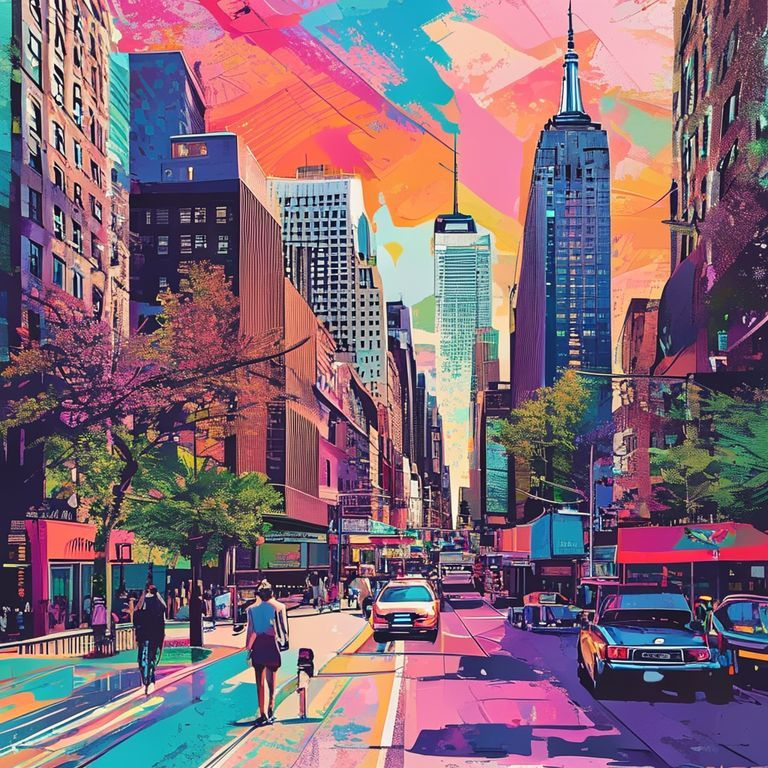

In [38]:
# Test the artist function - completely free!
image = artist("New York City")
display(image)

In [44]:
def talker(message):
    # Using gTTS - completely FREE text-to-speech!
    # No API key required, works offline-ish (needs internet for Google's service)
    try:
        tts = gTTS(text=message, lang='en', slow=False)
        audio_bytes = BytesIO()
        tts.write_to_fp(audio_bytes)
        audio_bytes.seek(0)
        return audio_bytes.read()
    except Exception as e:
        print(f"TTS error: {e}")
        return None

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [43]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        try:
            image = artist(cities[0])
        except Exception as e:
            print(f"Image generation failed for {cities[0]}: {e}")
            image = None
    
    return history, voice, image

In [45]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [46]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7888
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>